In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, utils, models
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import datasets

**Question 1 — Charger et normaliser CIFAR-10**

In [ ]:
# Charger CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normaliser entre 0 et 1
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Train:", train_images.shape, train_labels.shape)
print("Test :", test_images.shape, test_labels.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


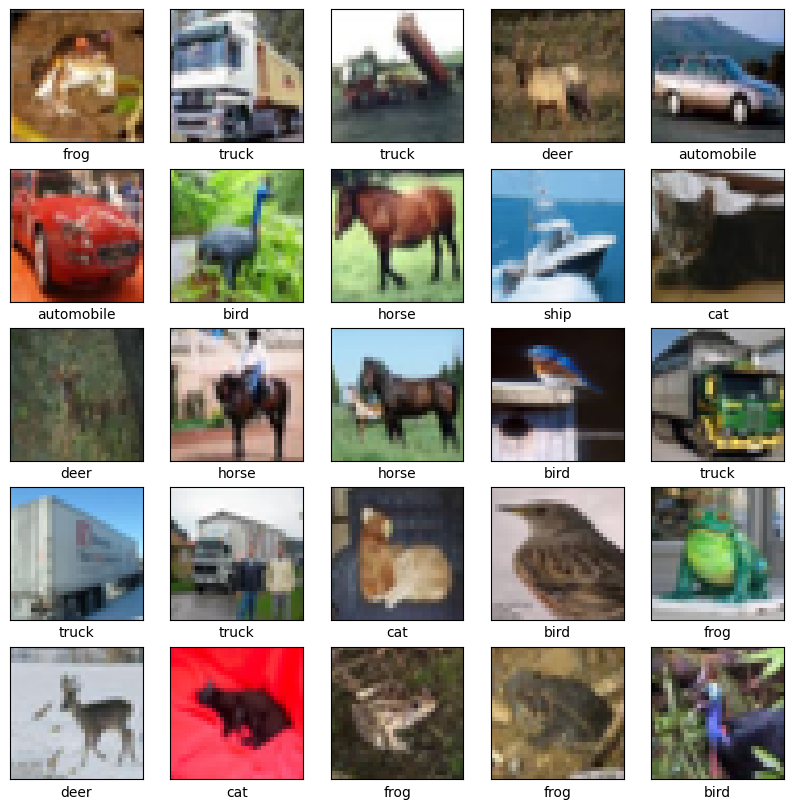

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

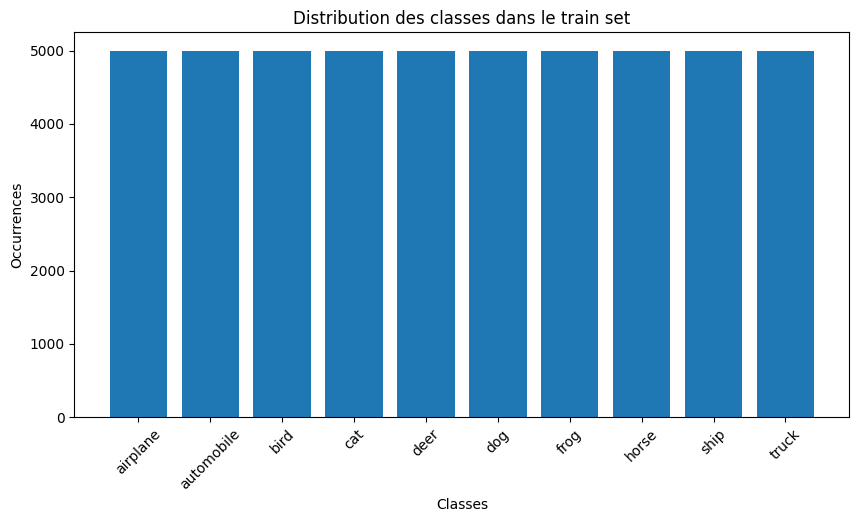

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(labels, class_names, title="Class Distribution"):
    # Convertir en tableau 1D si besoin
    labels = np.array(labels).flatten()

    # Compter occurrences
    counts = np.bincount(labels, minlength=len(class_names))

    # Affichage du graphique
    plt.figure(figsize=(10,5))
    plt.bar(class_names, counts)
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Occurrences")
    plt.xticks(rotation=45)
    plt.show()

# Utilisation :
plot_class_distribution(train_labels, class_names, "Distribution des classes dans le train set")


In [ ]:
from tensorflow.keras import models, layers

def build_simple_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_simple_cnn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels,
                    epochs=10,
                    validation_data=(test_images, test_labels))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3644 - loss: 1.7189 - val_accuracy: 0.5649 - val_loss: 1.2323
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5785 - loss: 1.1894 - val_accuracy: 0.6320 - val_loss: 1.0491
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6464 - loss: 1.0099 - val_accuracy: 0.6538 - val_loss: 0.9877
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6797 - loss: 0.9095 - val_accuracy: 0.6657 - val_loss: 0.9457
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7093 - loss: 0.8261 - val_accuracy: 0.6927 - val_loss: 0.8851
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7320 - loss: 0.7588 - val_accuracy: 0.7013 - val_loss: 0.8500
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7498 - loss: 0.7130 - val_accuracy: 0.7098 - val_loss: 0.8435
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7682 - loss: 0.6667 -

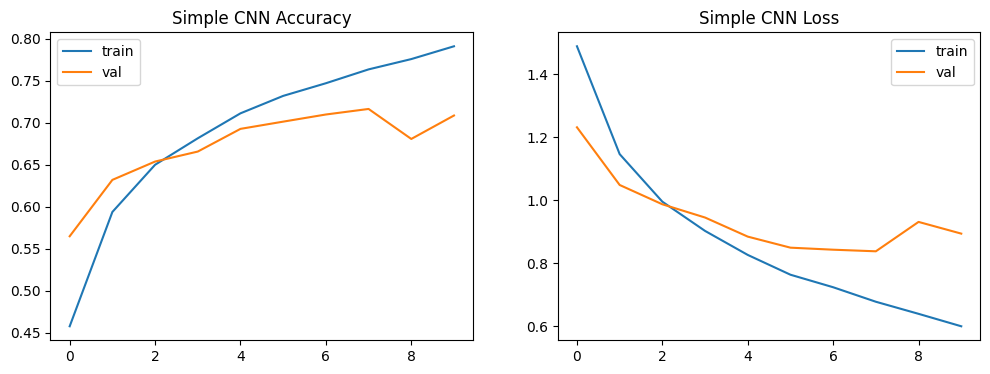

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model"):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.legend(['train','val'])

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.legend(['train','val'])
    plt.show()

plot_history(history, "Simple CNN")

**Question 2 — Redimensionner en 224×224×3**

Redimensionner les images de l'ensemble de données CIFAR-10 à la nouvelle dimension de
224 ×224, afin de les adapter à l'entrée des architectures populaires de CNN.

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32
TARGET_SIZE = (224, 224)

# Créer dataset train
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(lambda x, y: (tf.image.resize(x, TARGET_SIZE), y))
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Créer dataset test
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.map(lambda x, y: (tf.image.resize(x, TARGET_SIZE), y))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


**Question 3 — Entraînement From Scratch (VGG16, Inception, ResNet50)**

⚠️ InceptionV3 require min 75×75 → redimensionner à 224×224

In [ ]:
from tensorflow.keras.applications import VGG16, InceptionV3, ResNet50

def build_scratch_model(base_fn, input_shape=(224,224,3)):
    base = base_fn(weights=None, include_top=False, input_shape=input_shape)

    x = layers.Flatten()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    output = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

**Entraîner chaque modèle**

* VGG16 From Scratch

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 385s 234ms/step - accuracy: 0.1444 - loss: 2.2670 - val_accuracy: 0.2108 - val_loss: 2.1335
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 220ms/step - accuracy: 0.3481 - loss: 1.7820 - val_accuracy: 0.4002 - val_loss: 1.6903
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 219ms/step - accuracy: 0.4455 - loss: 1.5578 - val_accuracy: 0.4354 - val_loss: 1.5666
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 219ms/step - accuracy: 0.5484 - loss: 1.3049 - val_accuracy: 0.5775 - val_loss: 1.2128
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 220ms/step - accuracy: 0.6382 - loss: 1.0480 - val_accuracy: 0.6066 - val_loss: 1.1889
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 219ms/step - accuracy: 0.7199 - loss: 0.8266 - val_accuracy: 0.5800 - val_loss: 1.4600
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 220ms/step - accuracy: 0.7958 - loss: 0.6009 - val_accuracy: 0.6161 - val_loss: 1.6213
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 343s 219ms/step - ac

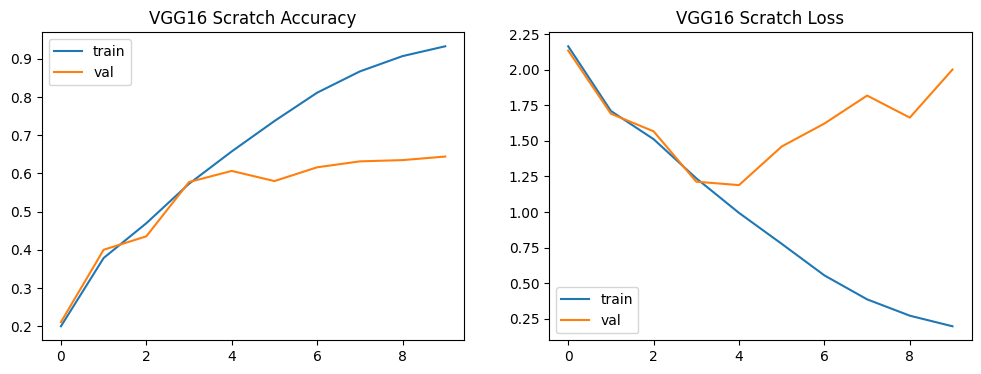

In [ ]:
# -----------------------------
# 2) Construire le modèle VGG16 from scratch
# -----------------------------
model_vgg = build_scratch_model(VGG16)

# -----------------------------
# 3) Entraîner le modèle
# -----------------------------
history_vgg = model_vgg.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

# -----------------------------
# 4) Tracer les courbes
# -----------------------------
plot_history(history_vgg, "VGG16 Scratch")

* RestNet From Scratch

In [ ]:
model_res = build_scratch_model(ResNet50)
history_vgg = model_res.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 276s 159ms/step - accuracy: 0.1425 - loss: 3.6135 - val_accuracy: 0.2161 - val_loss: 1.9325
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.2327 - loss: 1.8786 - val_accuracy: 0.3027 - val_loss: 1.7907
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.3295 - loss: 1.6768 - val_accuracy: 0.3790 - val_loss: 1.6556
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.4131 - loss: 1.5289 - val_accuracy: 0.4690 - val_loss: 1.4322
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.4719 - loss: 1.4105 - val_accuracy: 0.4733 - val_loss: 1.4093
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 232s 148ms/step - accuracy: 0.5129 - loss: 1.2974 - val_accuracy: 0.5039 - val_loss: 1.3536
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 148ms/step - accuracy: 0.5558 - loss: 1.1780 - val_accuracy: 0.4803 - val_loss: 1.4505
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 147ms/step - ac

NameError: name 'history_res' is not defined

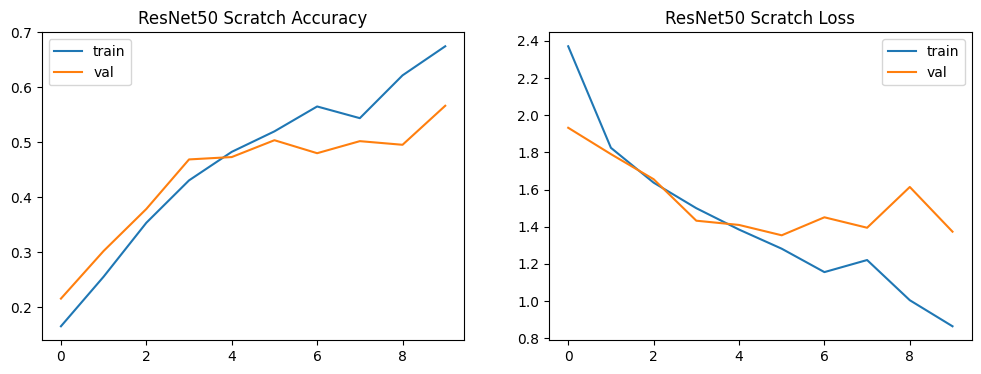

In [ ]:
plot_history(history_vgg, "ResNet50 Scratch")

* Inception From Scratch

  ⚠️ Inception nécessite input 299×299

In [ ]:
TARGET_SIZE_INC = (299, 299)

train_inc = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_inc = train_inc.map(lambda x, y: (tf.image.resize(x, TARGET_SIZE_INC), y))
train_inc = train_inc.batch(32).prefetch(tf.data.AUTOTUNE)

test_inc = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_inc = test_inc.map(lambda x, y: (tf.image.resize(x, TARGET_SIZE_INC), y))
test_inc = test_inc.batch(32).prefetch(tf.data.AUTOTUNE)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 429s 245ms/step - accuracy: 0.2407 - loss: 2.1093 - val_accuracy: 0.4004 - val_loss: 1.6660
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 351s 225ms/step - accuracy: 0.4559 - loss: 1.4660 - val_accuracy: 0.5162 - val_loss: 1.3462
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 351s 225ms/step - accuracy: 0.5486 - loss: 1.2481 - val_accuracy: 0.5322 - val_loss: 1.3495
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 351s 225ms/step - accuracy: 0.6095 - loss: 1.0843 - val_accuracy: 0.5653 - val_loss: 1.2481
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 351s 224ms/step - accuracy: 0.6661 - loss: 0.9347 - val_accuracy: 0.5264 - val_loss: 1.3532
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 350s 224ms/step - accuracy: 0.6819 - loss: 0.8863 - val_accuracy: 0.6124 - val_loss: 1.1466
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 351s 225ms/step - accuracy: 0.6879 - loss: 0.8762 - val_accuracy: 0.5818 - val_loss: 1.2181
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 351s 224ms/step - ac

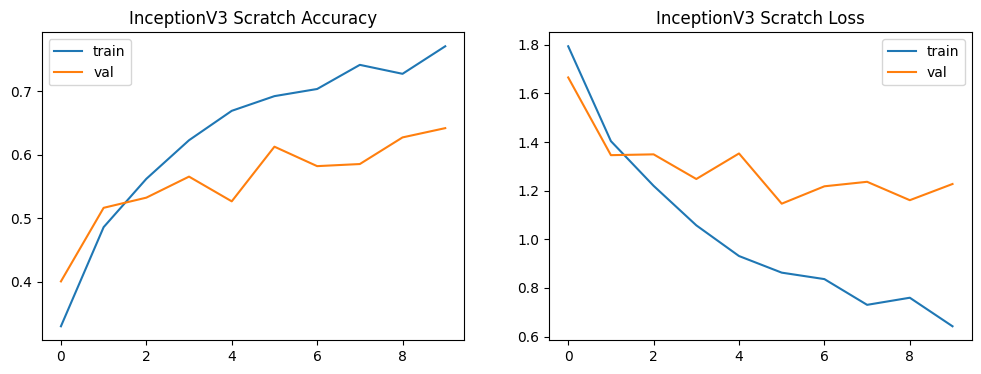

In [ ]:
model_inc = build_scratch_model(InceptionV3, input_shape=(299,299,3))

history_inc = model_inc.fit(
    train_inc,
    epochs=10,
    validation_data=test_inc
)

plot_history(history_inc, "InceptionV3 Scratch")


**Question 4 — Transfer Learning**

In [ ]:
def build_transfer_model(base_fn, input_shape=(224,224,3)):
    base = base_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # Freeze backbone

    x = layers.Flatten()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    output = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

* Entraîner VGG16 en Transfer Learning

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - accuracy: 0.1583 - loss: 2.2248 - val_accuracy: 0.2579 - val_loss: 2.0873
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.3900 - loss: 1.6449 - val_accuracy: 0.3048 - val_loss: 2.0947
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.4537 - loss: 1.4813 - val_accuracy: 0.3348 - val_loss: 2.0991
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.4890 - loss: 1.3926 - val_accuracy: 0.3419 - val_loss: 2.0721
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.5121 - loss: 1.3318 - val_accuracy: 0.3495 - val_loss: 2.0666
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.5302 - loss: 1.2856 - val_accuracy: 0.3570 - val_loss: 2.0573
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.5443 - loss: 1.2499 - val_accuracy: 0.3388 - val_loss: 2.1791
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 

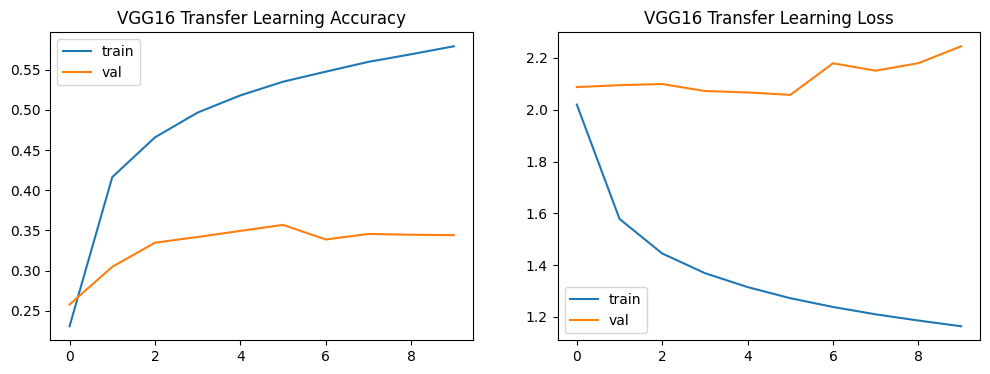

In [ ]:
model_vgg_tl = build_transfer_model(VGG16)
history_vgg_tl = model_vgg_tl.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)
plot_history(history_vgg_tl, "VGG16 Transfer Learning")

* Entraîner RestNet50 en Transfer Learning

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 98s 57ms/step - accuracy: 0.0956 - loss: 3.5440 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0935 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0936 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0936 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0936 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0935 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0935 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.0935 -

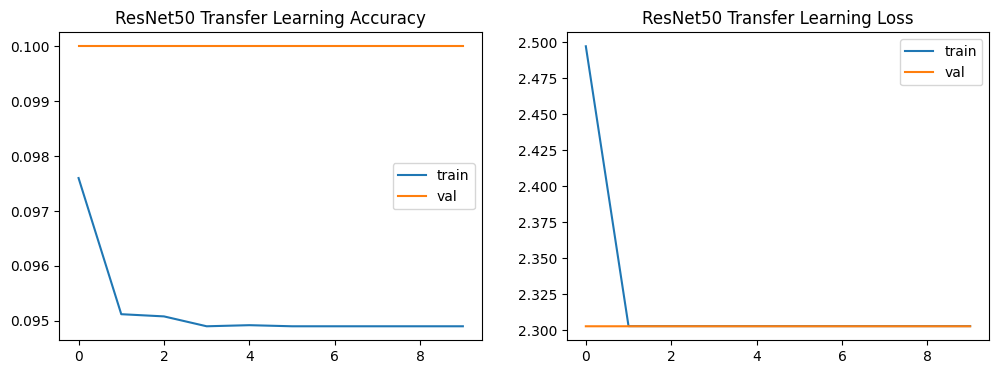

In [ ]:
model_res_tl = build_transfer_model(ResNet50)
history_res_tl = model_res_tl.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)
plot_history(history_res_tl, "ResNet50 Transfer Learning")

* Entraîner InceptionV3 en Transfer Learning

In [ ]:
model_inc_tl = build_transfer_model(InceptionV3, input_shape=(299,299,3))
history_inc_tl = model_inc_tl.fit(
    train_inc, train_labels,
    epochs=10,
    validation_data=(test_inc, test_labels)
)
plot_history(history_inc_tl, "InceptionV3 Transfer Learning")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 84ms/step - accuracy: 0.7191 - loss: 0.9801 - val_accuracy: 0.8459 - val_loss: 0.4467
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 121s 77ms/step - accuracy: 0.8865 - loss: 0.3230 - val_accuracy: 0.8571 - val_loss: 0.4353
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 121s 77ms/step - accuracy: 0.9339 - loss: 0.1939 - val_accuracy: 0.8594 - val_loss: 0.4794
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 121s 77ms/step - accuracy: 0.9672 - loss: 0.1022 - val_accuracy: 0.8561 - val_loss: 0.5588
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 77ms/step - accuracy: 0.9777 - loss: 0.0659 - val_accuracy: 0.8488 - val_loss: 0.6727
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 77ms/step - accuracy: 0.9832 - loss: 0.0487 - val_accuracy: 0.8514 - val_loss: 0.6901
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 121s 77ms/step - accuracy: 0.9906 - loss: 0.0293 - val_accuracy: 0.8583 - val_loss: 0.6702
Epoch 8/10
1563/15

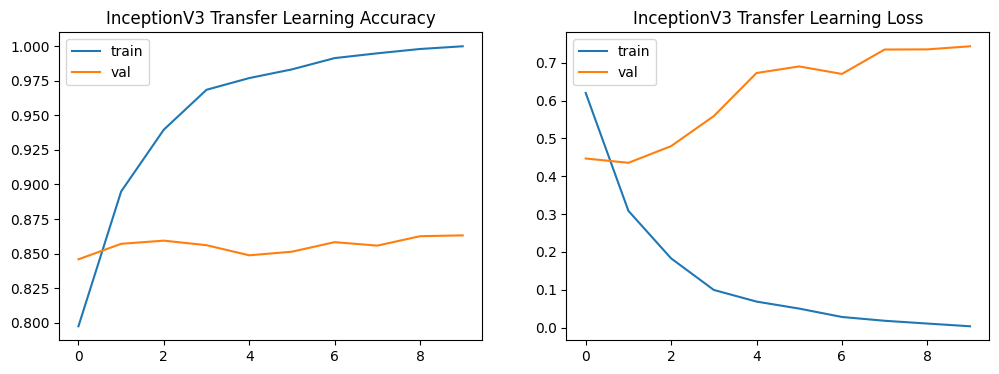

In [ ]:
model_inc_tl = build_transfer_model(InceptionV3, input_shape=(299,299,3))

history_inc_tl = model_inc_tl.fit(
    train_inc,
    epochs=10,
    validation_data=test_inc
)

plot_history(history_inc_tl, "InceptionV3 Transfer Learning")

**Question 6 — Matrice de confusion**

In [ ]:
def plot_confusion(model, dataset, title="Model"):
    """Matrice de confusion avec nombres annotés"""

    # Récupération des prédictions
    if isinstance(dataset, tuple):
        x_test, y_test = dataset
        y_pred = np.argmax(model.predict(x_test), axis=1)
        y_true = y_test.flatten()
    else:
        y_true, y_pred = [], []
        for x, y in dataset:
            y_pred.extend(np.argmax(model.predict(x), axis=1))
            y_true.extend(y.numpy().flatten())

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    acc = np.trace(cm) / np.sum(cm) * 100

    # Affichage avec nombres
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  # annot=True pour nombres
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title(f'{title} - Accuracy: {acc:.2f}%', fontweight='bold', fontsize=10)
    plt.xlabel('Predicted', fontsize=8)
    plt.ylabel('True', fontsize=8)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
test_ds_small = test_ds.take(100)  # ici  on a 32 images par batch parceque le data et déja batcher
#train_ds_small = train_ds.unbatch().take(100).batch(32)  si tu peut prondre selement 100 images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━

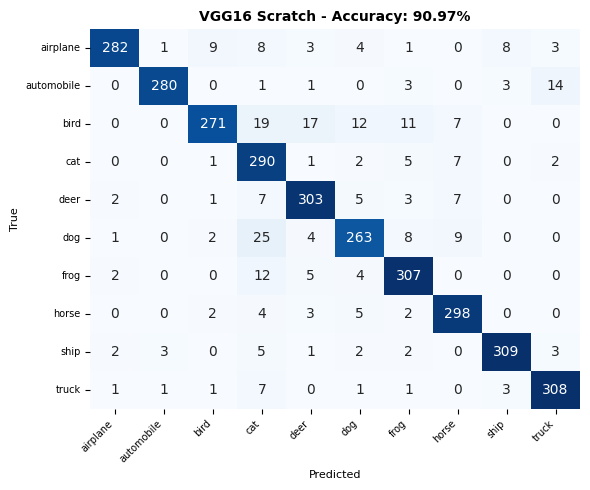

In [ ]:
 # From Scratch
plot_confusion(model_vgg, train_ds_small, "VGG16 Scratch")
# plot_confusion_no_plot(vgg_model, test_ds, title="VGG16")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━

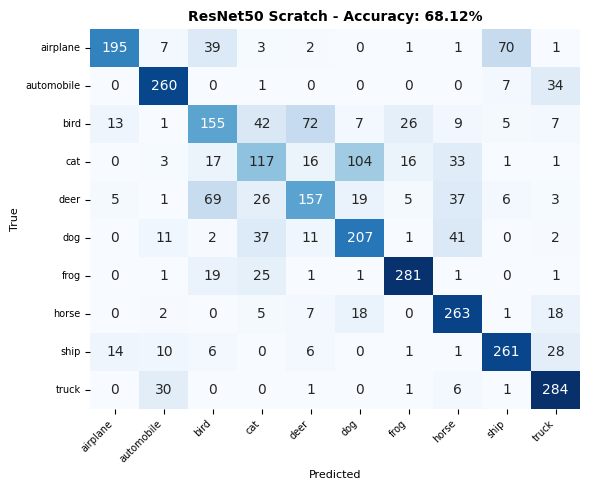

In [ ]:
plot_confusion(model_res, train_ds_small, "ResNet50 Scratch")

In [ ]:
test_inc_small = train_inc.take(100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

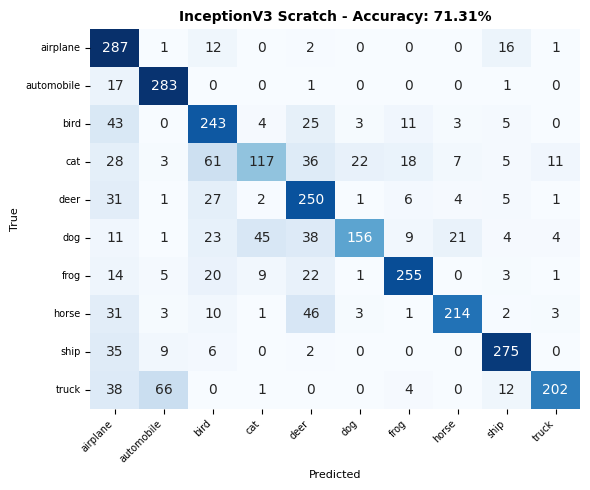

In [ ]:
plot_confusion(model_inc, test_inc_small, "InceptionV3 Scratch")

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
import tensorflow as tf

# --- Fonction générique de Transfer Learning ---
def build_transfer_model(base_fn, input_shape=(224,224,3), num_classes=10):
    """
    base_fn : fonction du modèle pré-entraîné (VGG16, ResNet50...)
    input_shape : taille des images
    num_classes : nombre de classes à prédire
    """
    # Charger le modèle pré-entraîné sans la couche de classification
    base = base_fn(weights='imagenet', include_top=False, input_shape=input_shape)

    # Geler le backbone pour le Transfer Learning de base
    base.trainable = False

    # Ajouter nos couches de classification
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    # Créer le modèle final
    model = models.Model(inputs=base.input, outputs=output)

    # Compiler le modèle
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# --- Exemple d'utilisation avec VGG16 ---
model_vgg_tl = build_transfer_model(VGG16)
history_vgg_tl = model_vgg_tl.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


I0000 00:00:1764263294.270952     110 service.cc:148] XLA service 0x7eaf8000c980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764263294.271784     110 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764263294.642703     110 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1563 ━━━━━━━━━━━━━━━━━━━━ 1:54 74ms/step - accuracy: 0.0547 - loss: 2.4301  

I0000 00:00:1764263302.443965     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 87ms/step - accuracy: 0.3879 - loss: 1.7307 - val_accuracy: 0.5544 - val_loss: 1.2630
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.5715 - loss: 1.2319 - val_accuracy: 0.5934 - val_loss: 1.1459
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6048 - loss: 1.1298 - val_accuracy: 0.6140 - val_loss: 1.0879
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6231 - loss: 1.0742 - val_accuracy: 0.6275 - val_loss: 1.0539
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6357 - loss: 1.0369 - val_accuracy: 0.6381 - val_loss: 1.0302
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6455 - loss: 1.0090 - val_accuracy: 0.6461 - val_loss: 1.0064
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6542 - loss: 0.9868 - val_accuracy: 0.6526 - val_loss: 0.9906
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6589 - lo

In [ ]:

# --- Exemple d'utilisation avec ResNet50 ---
model_resnet_tl = build_transfer_model(ResNet50)
history_resnet_tl = model_resnet_tl.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 57ms/step - accuracy: 0.1281 - loss: 2.3006 - val_accuracy: 0.1681 - val_loss: 2.1671
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.2292 - loss: 2.0653 - val_accuracy: 0.2568 - val_loss: 2.0079
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.2582 - loss: 1.9871 - val_accuracy: 0.2900 - val_loss: 1.9328
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.2814 - loss: 1.9368 - val_accuracy: 0.3071 - val_loss: 1.8917
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.3002 - loss: 1.8968 - val_accuracy: 0.3157 - val_loss: 1.8716
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.3150 - loss: 1.8632 - val_accuracy: 0.3242 - val_loss: 1.8597
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.3267 - loss: 1.8360 - val_accuracy: 0.3390 - val_loss: 1.8354
Epoch 8/10
1563/1563 ━━━━

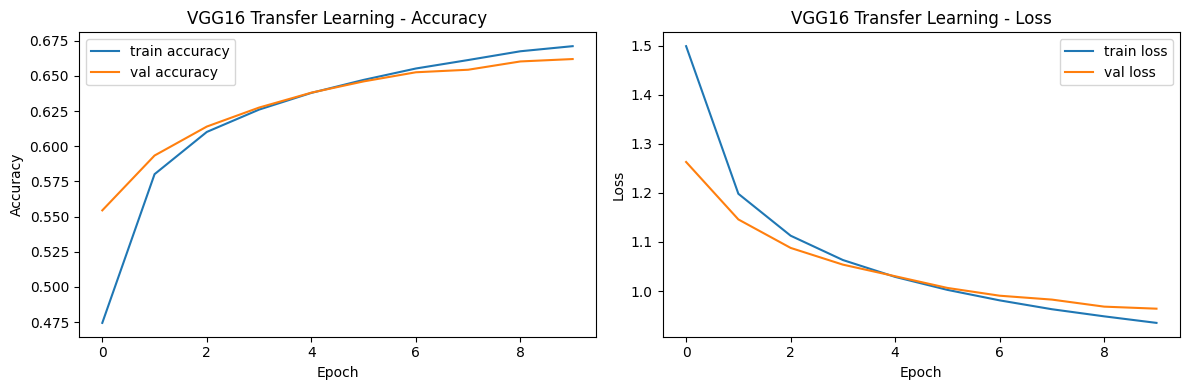

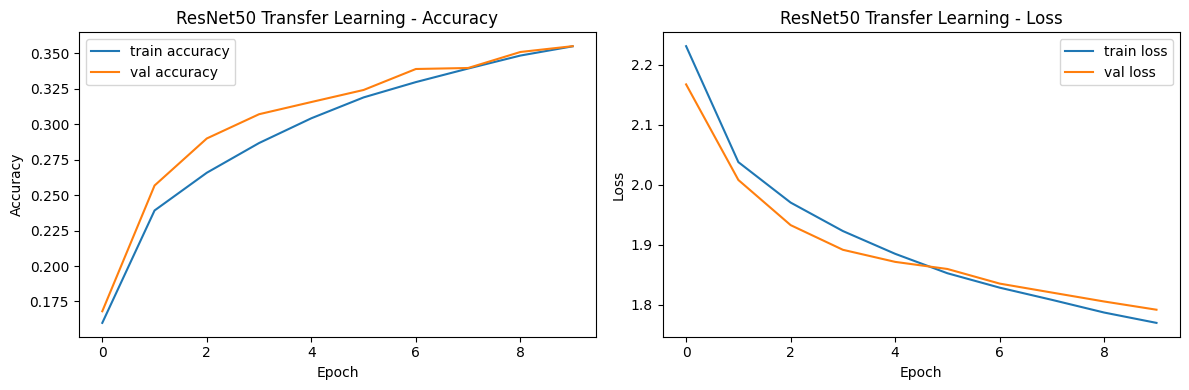

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model History"):
    plt.figure(figsize=(12,4))

    # ----- Accuracy -----
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.title(title + " - Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # ----- Loss -----
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(title + " - Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


# Afficher l'historique
plot_history(history_vgg_tl, "VGG16 Transfer Learning")
plot_history(history_resnet_tl, "ResNet50 Transfer Learning")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1

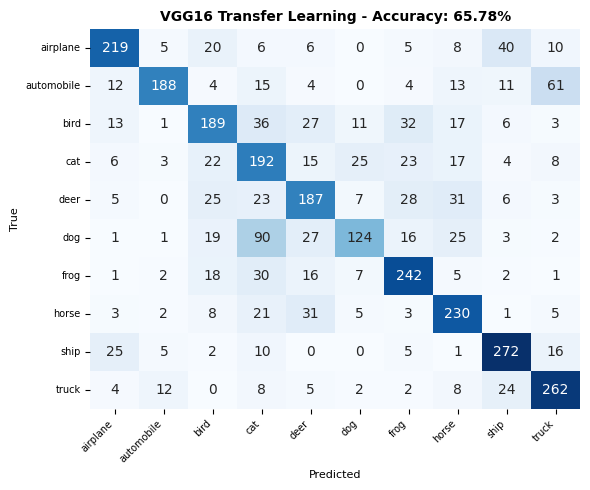

In [ ]:
import seaborn as sns

plot_confusion(model_vgg_tl, test_ds_small, "VGG16 Transfer Learning")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━

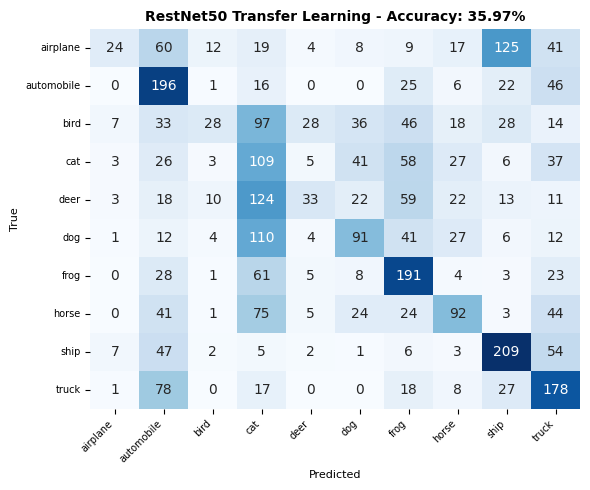

In [ ]:
plot_confusion(model_resnet_tl, test_ds_small, "RestNet50 Transfer Learning")

In [ ]:

# --- Exemple d'utilisation avec inc ---
model_inc_tl = build_transfer_model(InceptionV3, input_shape=(299,299,3))
history_inc_tl = model_resnet_tl.fit(
    train_inc,
    epochs=10,
    validation_data=test_inc
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 163s 99ms/step - accuracy: 0.1407 - loss: 3.2904 - val_accuracy: 0.1751 - val_loss: 2.2238
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.1895 - loss: 2.1916 - val_accuracy: 0.1998 - val_loss: 2.1498
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 94ms/step - accuracy: 0.2111 - loss: 2.1214 - val_accuracy: 0.2260 - val_loss: 2.0942
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.2339 - loss: 2.0611 - val_accuracy: 0.2367 - val_loss: 2.0646
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 93ms/step - accuracy: 0.2504 - loss: 2.0140 - val_accuracy: 0.2665 - val_loss: 1.9982
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.2613 - loss: 1.9773 - val_accuracy: 0.2912 - val_loss: 1.9462
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 93ms/step - accuracy: 0.2730 - loss: 1.9489 - val_accuracy: 0.3009 - val_loss: 1.9114
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 93ms/step - accuracy: 

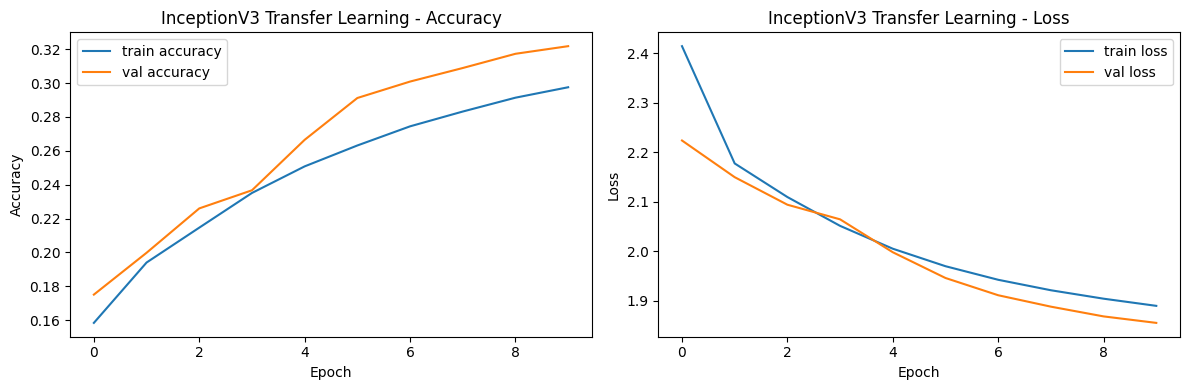

In [ ]:
plot_history(history_inc_tl, "InceptionV3 Transfer Learning")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

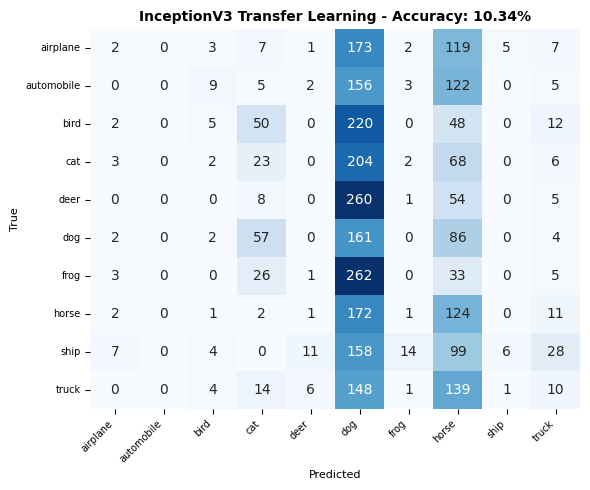

In [ ]:
plot_confusion(model_inc_tl, test_inc_small, "InceptionV3 Transfer Learning")